<h3>Created by: Christopher Kuan
<h3>Date: 25/5/2026

<h1> TSP QAOA timeslot (reduced variables)

# Setup

In [1]:
import matplotlib.pyplot as plt
from rustworkx.visualization import mpl_draw as draw_graph
import networkx as nx
import numpy as np
from scipy.optimize import minimize

from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit.primitives import StatevectorSampler

from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

from qiskit_optimization.applications import Tsp
from qiskit_optimization.converters import QuadraticProgramToQubo

from qiskit_aer import AerSimulator

from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_algorithms.utils import algorithm_globals

import math
import time

# Arguments

In [2]:
# General
n = 5                    # number of nodes
node_color = "r"        # color of node, "r" - red, "b" - blue, "g" - green, "y" - yellow, "m" - magenta
penalty_weight = 280    # Good practice is max coeeficient * number of qubits

# Simple QAOA
algorithm_globals_random_seed = 10598
state_vector_sampler_seed = 42
p_layer_simple = 2      # number of layers of QAOA (simple)

# Advanced QAOA
p_layer_advanced = 3   # number of layers of QAOA (advanced)
initial_gamma = 0.1
initial_beta = 0.5
method="COBYQA"         # type of classical solver for QAOA
tol=1e-3                # tolerance for termination

# Helper functions

In [3]:
def draw_graph(G, colors, pos):
    ax = plt.axes(frameon=True)
    nx.draw_networkx(G, node_color=colors, node_size=600, alpha=0.8, ax=ax, pos=pos)
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(G, pos=pos, edge_labels=edge_labels)
    
def normalize_hamiltonian(cost_hamiltonian):
    coeffs = np.abs(cost_hamiltonian.coeffs)
    scale = np.max(coeffs)
    return cost_hamiltonian / scale

def check_feasibility (bitstring):
    # Split into even parts
    bit_list = [bitstring[i:i+n-1] for i in range(0, num_qubits, n-1)]
    # Check if each part has only one 1 and the positions do not overlap
    position_history = []
    for bits in bit_list:
        if bits.count('1') != 1:
            return 1
        else:
            position = bits.find('1')
            if position in position_history:
                return 1
            position_history.append(position)
    return 0

def filter_result(eigenstate):
    sorted_eigenstate = sorted(eigenstate.items(), key=lambda x: x[1], reverse=True)

    invalid_index = []
    for i in range(len(sorted_eigenstate)):
        if check_feasibility(sorted_eigenstate[i][0]) == 1:
            invalid_index.append(i)
    
    invalid_index = invalid_index[::-1]
    
    for i in invalid_index:        
        sorted_eigenstate.pop(i)
    
    return sorted_eigenstate

def plot_result_distribution(eigenstate, top=5):
    if len(eigenstate) < top:
        raise ValueError("Top value exceed amount of valid results")
    
    top_results = eigenstate[:top]
    
    # Plot result
    x = [result[0] for result in top_results]
    y = [result[1] for result in top_results]
    plt.figure(figsize=(10,6))
    bars = plt.bar(list(x), list(y), color="tab:grey")
    plt.title("Result distribution")
    plt.xlabel("Bitstrings (X_n,...,X_0)")
    plt.xticks(rotation=45)
    plt.ylabel("Probability")
    if top < 4:
        maxpurple = math.floor(top/2)
    else:
        maxpurple = 4
    for i in range(maxpurple):
        bars[i].set_color("tab:purple")
    plt.show()

def show_path(eigenstate, cost_matrix):
    bitstring = eigenstate[0][0][::-1]
    bit_list = [bitstring[i:i+n-1] for i in range(0, num_qubits, n-1)]
    
    # Find the time at which the salesman is at each node
    time_list = []
    for bit in bit_list:
        time_list.append(bit.find('1'))
    
    # Construct the path
    path = [None] * (n-1)
    node_count = 1
    for time in time_list:
        path[time] = node_count
        node_count += 1
    
    # Printing result
    print("Optimal path")
    print(0, "-->", end=" ")
    for node in path:
        print(node, "-->", end=" ")
    print(0)
    
    # Finding cost
    path.insert(0, 0)
    path.insert(len(path), 0)
    cost = 0
    for node in range(0, len(path)-1):
        cost += cost_matrix[path[node]][path[node+1]]
        print(path[node], path[node+1])
    return cost

# Getting graph

distance
 [[ 0. 60. 73. 22. 36.]
 [60.  0. 87. 78. 60.]
 [73. 87.  0. 64. 38.]
 [22. 78. 64.  0. 35.]
 [36. 60. 38. 35.  0.]]


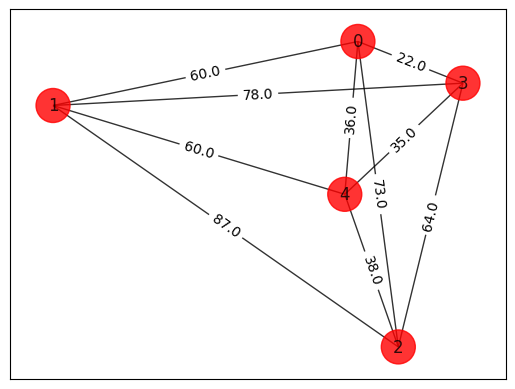

In [4]:
num_qubits = (n-1)**2
tsp = Tsp.create_random_instance(n, seed=561)
cost_matrix = nx.to_numpy_array(tsp.graph)
print("distance\n", cost_matrix)

colors = [node_color for node in tsp.graph.nodes]
pos = [tsp.graph.nodes[node]['pos'] for node in tsp.graph.nodes]
draw_graph(tsp.graph, colors, pos)

# Advanced method (Constructing own Hamiltonian and QAOA)
## Constructing Ising Hamiltonian

In [5]:
def build_paulis(cost_matrix, penalty, n) -> list[tuple[str, list[int], float]]:
    pauli_list = []
    # Make a list of tuples that has ("gate type", [which qubit it corresponds to], coeff)
    row, col = cost_matrix.shape
    
    # Build linear terms
    count = 0
    for i in range(1, row):
        for j in range(1, col):
            weight = sum(cost_matrix[i][:]) * -0.5 + penalty*(3-n)
            pauli_list.append(("Z", [count], weight))
            count += 1

    # Build quadratic terms
    count_firstZ = 0
    count_secondZ = 1
    for i in range(row*col):
        for j in range(i+1, row*col):
            from_node = int(math.floor(i / n))
            from_time = int(i % n)
            to_node = int(math.floor(j / n))
            to_time = int(j % n)
            if from_node != 0 and from_time != 0 and to_node != 0 and to_time != 0:
                weight = cost_matrix[from_node][to_node] * 0.25 * int(from_time != to_time) + penalty / 2 * int(from_node == to_node) + penalty / 2 * int(from_time == to_time)
                pauli_list.append(("ZZ", [count_firstZ, count_secondZ], weight))
                count_secondZ += 1
                if count_secondZ >= num_qubits:
                    count_firstZ += 1
                    count_secondZ = count_firstZ + 1
            
    return pauli_list

pauli_list = build_paulis(cost_matrix=cost_matrix, penalty=penalty_weight, n=n)
cost_hamiltonian = SparsePauliOp.from_sparse_list(pauli_list, num_qubits=num_qubits)
normalized_hamiltonian = normalize_hamiltonian(cost_hamiltonian)
print("Cost Function Hamiltonian:", normalized_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIIZII', 'IIIIIIIIIIIIZIII', 'IIIIIIIIIIIZIIII', 'IIIIIIIIIIZIIIII', 'IIIIIIIIIZIIIIII', 'IIIIIIIIZIIIIIII', 'IIIIIIIZIIIIIIII', 'IIIIIIZIIIIIIIII', 'IIIIIZIIIIIIIIII', 'IIIIZIIIIIIIIIII', 'IIIZIIIIIIIIIIII', 'IIZIIIIIIIIIIIII', 'IZIIIIIIIIIIIIII', 'ZIIIIIIIIIIIIIII', 'IIIIIIIIIIIIIIZZ', 'IIIIIIIIIIIIIZIZ', 'IIIIIIIIIIIIZIIZ', 'IIIIIIIIIIIZIIIZ', 'IIIIIIIIIIZIIIIZ', 'IIIIIIIIIZIIIIIZ', 'IIIIIIIIZIIIIIIZ', 'IIIIIIIZIIIIIIIZ', 'IIIIIIZIIIIIIIIZ', 'IIIIIZIIIIIIIIIZ', 'IIIIZIIIIIIIIIIZ', 'IIIZIIIIIIIIIIIZ', 'IIZIIIIIIIIIIIIZ', 'IZIIIIIIIIIIIIIZ', 'ZIIIIIIIIIIIIIIZ', 'IIIIIIIIIIIIIZZI', 'IIIIIIIIIIIIZIZI', 'IIIIIIIIIIIZIIZI', 'IIIIIIIIIIZIIIZI', 'IIIIIIIIIZIIIIZI', 'IIIIIIIIZIIIIIZI', 'IIIIIIIZIIIIIIZI', 'IIIIIIZIIIIIIIZI', 'IIIIIZIIIIIIIIZI', 'IIIIZIIIIIIIIIZI', 'IIIZIIIIIIIIIIZI', 'IIZIIIIIIIIIIIZI', 'IZIIIIIIIIIIIIZI', 'ZIIIIIIIIIIIIIZI', 'IIIIIIIIIIIIZZII', 'IIIIIIIIIIIZIZII', 'IIIIIIIIIIZIIZII'

## Constructing QAOA

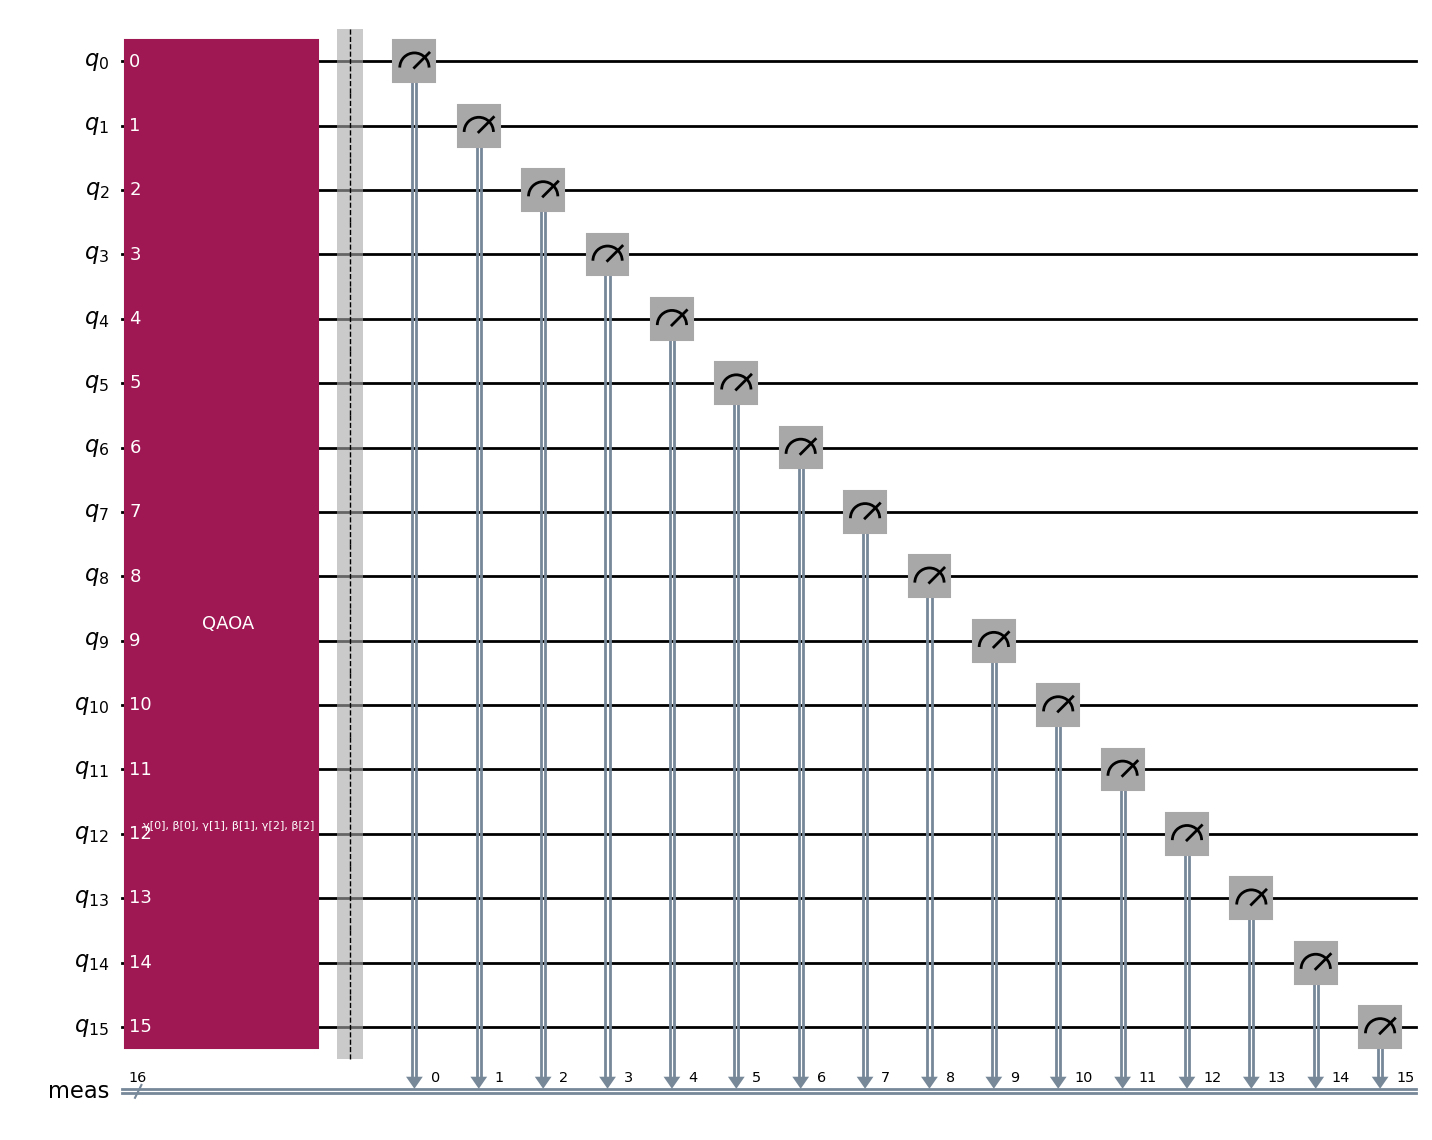

In [6]:
circuit = QAOAAnsatz(cost_operator=normalized_hamiltonian, reps=p_layer_advanced)
circuit.measure_all()

# Show circuit
circuit.draw("mpl")

## Setting up training

In [7]:
##### Simulator #####
backend = AerSimulator()
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
candidate_circuit = pm.run(circuit)
# candidate_circuit.draw("mpl", fold=False, idle_wires=False)

# Initial parameters
init_params = [initial_beta] * p_layer_advanced + [initial_gamma] * p_layer_advanced

# Objective function to minimize.
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)    
    pub = (ansatz, isa_hamiltonian, params)

    job = estimator.run([pub])
    
    results = job.result()[0]
    cost = results.data.evs
    
    objective_func_vals.append(cost)
    
    return cost

## Training QAOA

In [8]:
objective_func_vals = [] # Global variable

advanced_start_time = time.time()
# Training
with Session(backend=backend) as session:
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 1000
    
    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    
    # Scipy minimize routine, minimize function does Minimization of scalar 
    # function of one or more variables.
    result = minimize(
        cost_func_estimator, # Objective function to be minimized
        init_params, # initial guess
        args=(candidate_circuit, normalized_hamiltonian, estimator), # extra arguments passed to the objective function and its derivatives
        method=method, # type of solver
        tol=tol, # tolerance for termination
    )
    
# Final loop to get result
optimized_circuit = candidate_circuit.assign_parameters(result.x)

sampler = Sampler(mode=backend)
sampler.options.default_shots = 10000

sampler.options.dynamical_decoupling.enable = True
sampler.options.dynamical_decoupling.sequence_type = "XY4"
sampler.options.twirling.enable_gates = True
sampler.options.twirling.num_randomizations = "auto"

pub = (optimized_circuit,)
job = sampler.run([pub], shots=int(1e4))
counts_int = job.result()[0].data.meas.get_int_counts()
counts_bin = job.result()[0].data.meas.get_counts()
shots = sum(counts_int.values())
final_distribution_int = {key: val / shots for key, val in counts_int.items()}
final_distribution_bin = {key: val / shots for key, val in counts_bin.items()}
advanced_end_time = time.time()
advanced_runtime = advanced_end_time - advanced_start_time

c:\Users\kjh\Desktop\VRPTW\Coding\venv\Lib\site-packages\qiskit_ibm_runtime\fake_provider\local_service.py:274: UserWarning: Options {'dynamical_decoupling': {'enable': True, 'sequence_type': 'XY4'}, 'twirling': {'enable_gates': True, 'num_randomizations': 'auto'}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


## Visualizing result

QAOA runtime: 10.9762 seconds


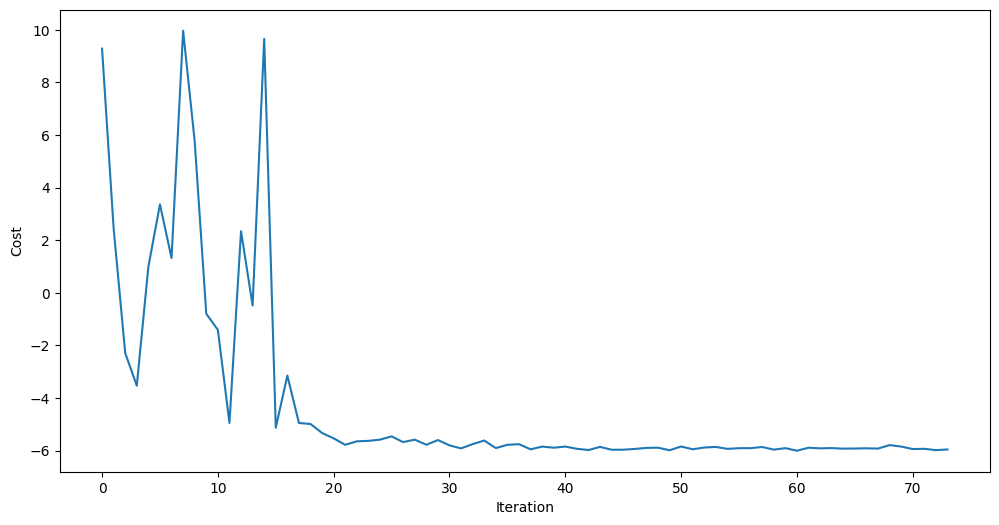

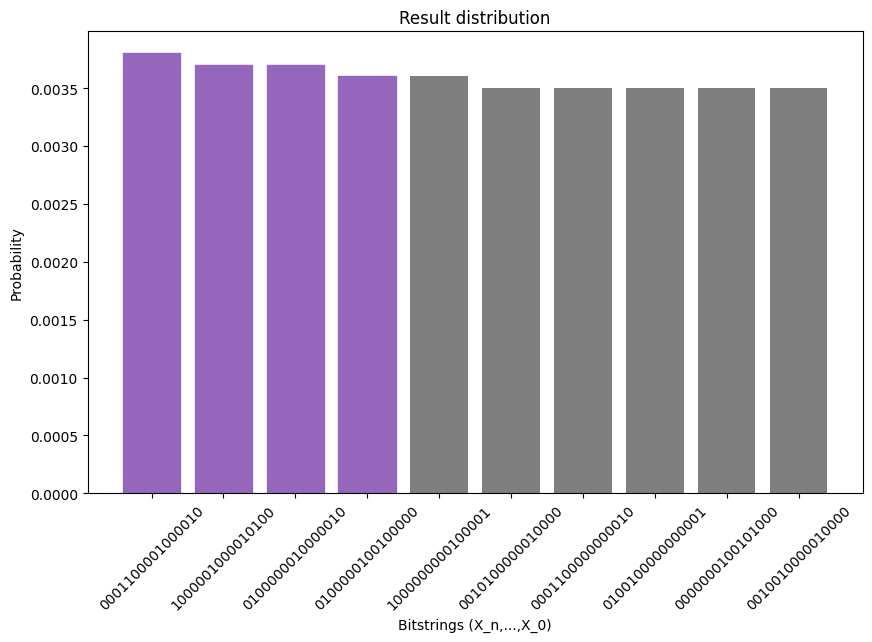

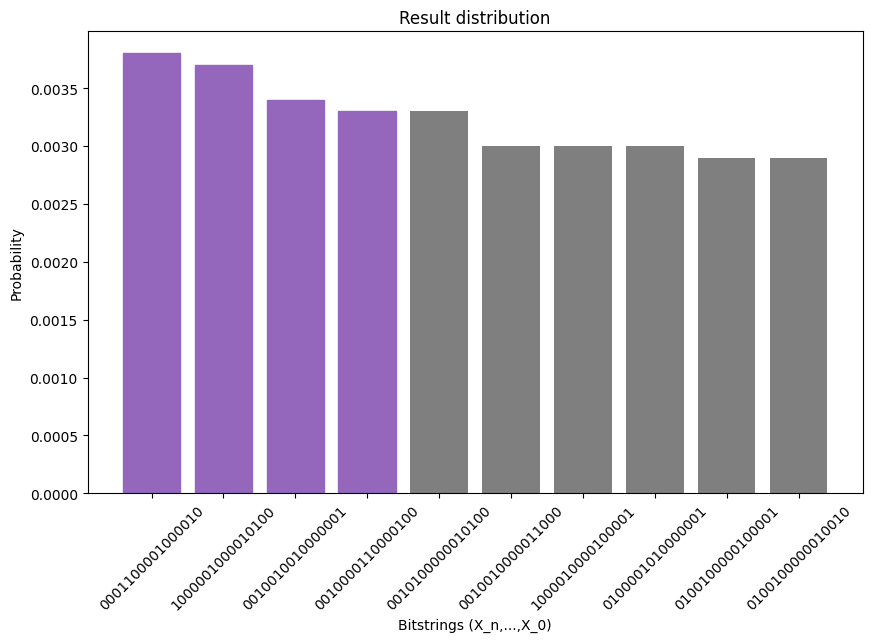

Optimal path
0 --> 4 --> 1 --> 2 --> 3 --> 0
0 4
4 1
1 2
2 3
3 0
Cost:  269.0


In [9]:
# Reporting runtime
print(f"QAOA runtime: {advanced_runtime:.4f} seconds")

plt.figure(figsize=(12,6))
plt.plot(objective_func_vals)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

filtered_sorted_eigenstate = filter_result(final_distribution_bin)
sorted_eigenstate = sorted(final_distribution_bin.items(), key=lambda x: x[1], reverse=True)

maxlen = len(filtered_sorted_eigenstate)
if maxlen >10:
    maxlen = 10
plot_result_distribution(sorted_eigenstate, top=maxlen)
plot_result_distribution(filtered_sorted_eigenstate, top=maxlen)
cost = show_path(filtered_sorted_eigenstate, cost_matrix)
print("Cost: ", cost)